# Quantitative and Qualitative Analysis: Stereo Depth Estimation

## Objective
This section focuses on implementing and analyzing **stereo depth estimation** using a deep learning-based stereo matching model (**RAFT-Stereo**).  
The goal is to evaluate its performance on the CARLA simulator dataset through **quantitative metrics** and **qualitative visualizations**.

## Step 1: Setup and Dataset Preparation
- Install required packages and clone the RAFT-Stereo repository.
- Download and extract the CARLA dataset (left/right stereo pairs and ground truth disparity maps).
- Prepare output folders for saving predicted disparity maps.


In [2]:
# Install gdown for downloading files from Google Drive
!pip install -q gdown

import gdown
import zipfile

# Google Drive file ID and output name for the dataset
file_id = "1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq"
output = "dataset.zip"

# Download the dataset zip file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)
# Extract the downloaded zip file into the 'dataset' folder

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")
# Clone the RAFT-Stereo repository from GitHub
!git clone https://github.com/princeton-vl/RAFT-Stereo.git

# Change the current working directory to the cloned RAFT-Stereo folder
%cd RAFT-Stereo

# Install PyTorch and Torchvision for running deep learning models
!pip install torch torchvision

# Install essential image processing and visualization libraries
!pip install opencv-python pillow matplotlib scikit-image tqdm


Downloading...
From (original): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq
From (redirected): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq&confirm=t&uuid=0917b03f-b51e-48cb-b53a-88c942905fd2
To: /content/dataset.zip
100%|██████████| 280M/280M [00:03<00:00, 74.9MB/s]


Cloning into 'RAFT-Stereo'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 87 (delta 40), reused 33 (delta 33), pack-reused 32 (from 1)
Receiving objects: 100% (87/87), 702.36 KiB | 2.33 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/RAFT-Stereo
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-ma

## Step 2: Model Initialization
- Load the RAFT-Stereo model with pre-trained **SceneFlow weights**.
- Move the model to the GPU (if available) for faster inference.
- Set the model to evaluation mode.


In [5]:
import os
import numpy as np
import torch
import cv2
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- Dataset and Output Paths ---
left_dir = "/content/dataset/3DCV00_data/data/images/left"        # Left stereo images
right_dir = "/content/dataset/3DCV00_data/data/images/right"      # Right stereo images
gt_disp_dir = "/content/dataset/3DCV00_data/data/images/gt_disp"  # Ground truth disparity maps
output_dir = "/content/predicted_disp"                            # Folder to save predicted disparity maps
os.makedirs(output_dir, exist_ok=True)

# --- Select Device (GPU if available) ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE
import sys
sys.path.append('/content/RAFT-Stereo/core')  # Add RAFT-Stereo core folder to Python path

from raft_stereo import RAFTStereo
from utils.utils import InputPadder

# --- Define Model Arguments ---
class Args:
    hidden_dims = [128, 128, 128]        # Hidden layer sizes
    corr_implementation = "reg"          # Correlation volume type
    shared_backbone = False              # Whether to share encoder backbone
    corr_levels = 4                      # Correlation pyramid levels
    corr_radius = 4                      # Correlation neighborhood radius
    n_downsample = 2                     # Downsampling factor
    context_norm = "batch"               # Batch normalization in context network
    slow_fast_gru = False                # Whether to use slow-fast GRU
    n_gru_layers = 3                     # Number of GRU layers
    mixed_precision = False              # Mixed precision inference (False for stability)

args = Args()

# --- Initialize Model ---
model = torch.nn.DataParallel(RAFTStereo(args)).to(DEVICE)

# --- Load Pretrained Weights ---
model.load_state_dict(torch.load("/content/raftstereo-sceneflow.pth"))

# Remove DataParallel wrapper for single-GPU inference
model = model.module

# --- Move to Device and Set to Evaluation Mode ---
model.to(DEVICE)
model.eval()


RAFTStereo(
  (cnet): MultiBasicEncoder(
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (relu1): ReLU(inplace=True)
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

## Step 3: Inference and Metric Calculation

- Predict disparity maps for all left/right image pairs in the CARLA dataset.
- Normalize predictions and compare them against ground truth disparity maps.
- Calculate standard evaluation metrics:
  1. **Mean Absolute Error (MAE)** – average absolute difference (normalized).
  2. **Root Mean Squared Error (RMSE)** – penalizes large errors more.
  3. **End-Point Error (EPE)** – average pixel disparity error (raw).
  4. **Bad-1** – percentage of pixels with disparity error >1px.


In [6]:
def load_image(imfile):
    img = np.array(Image.open(imfile)).astype(np.uint8)
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(img).permute(2,0,1).float()[None]

MAEs, RMSEs, EPEs, BAD1s = [], [], [], []
file_names = sorted(os.listdir(left_dir))
max_range = 255.0

for fname in tqdm(file_names):
    left_path, right_path, gt_path = (os.path.join(left_dir, fname),
                                      os.path.join(right_dir, fname),
                                      os.path.join(gt_disp_dir, fname))

    if not os.path.exists(right_path) or not os.path.exists(gt_path):
        continue

    # Predict disparity
    image1, image2 = load_image(left_path).to(DEVICE), load_image(right_path).to(DEVICE)
    image1, image2 = InputPadder(image1.shape).pad(image1, image2)

    with torch.no_grad():
        _, pred_disp = model(image1, image2, iters=20, test_mode=True)
        disp = pred_disp[0].cpu().numpy().squeeze()

    # Save predicted disparity visualization
    cv2.imwrite(os.path.join(output_dir, fname),
                cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))

    # Load GT disparity
    gt_disp = np.array(Image.open(gt_path)).astype(np.float32)
    if gt_disp.shape != disp.shape:
        gt_disp = cv2.resize(gt_disp, (disp.shape[1], disp.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Normalize & Flip
    pred_norm = 1 - (disp / max_range)
    gt_norm = gt_disp / max_range

    # Metrics
    MAEs.append(np.mean(np.abs(pred_norm - gt_norm)))
    RMSEs.append(np.sqrt(np.mean((pred_norm - gt_norm)**2)))
    EPEs.append(np.mean(np.abs(disp - gt_disp)))
    BAD1s.append(np.mean(np.abs(disp - gt_disp) > 1) * 100)

print("\n=========== RAFT-Stereo Results ===========")
print(f"Mean MAE (Flipped): {np.mean(MAEs):.4f}")
print(f"Mean RMSE (Flipped): {np.mean(RMSEs):.4f}")
print(f"Mean EPE: {np.mean(EPEs):.4f}")
print(f"Bad-1: {np.mean(BAD1s):.2f}%")


  0%|          | 0/50 [00:00<?, ?it/s]/content/RAFT-Stereo/core/raft_stereo.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/RAFT-Stereo/core/raft_stereo.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
100%|██████████| 50/50 [04:02<00:00,  4.85s/it]


=========== RAFT-Stereo Results ===========
Mean MAE (Flipped): 1.0023
Mean RMSE (Flipped): 1.0025
Mean EPE: 78.4610
Bad-1: 99.99%


## Step 4: Qualitative Analysis – Sample Prediction

Visualizing a single example to inspect performance:
- Input left RGB image
- Predicted disparity map (normalized)
- Ground truth disparity map
- Absolute error map (MAE displayed)


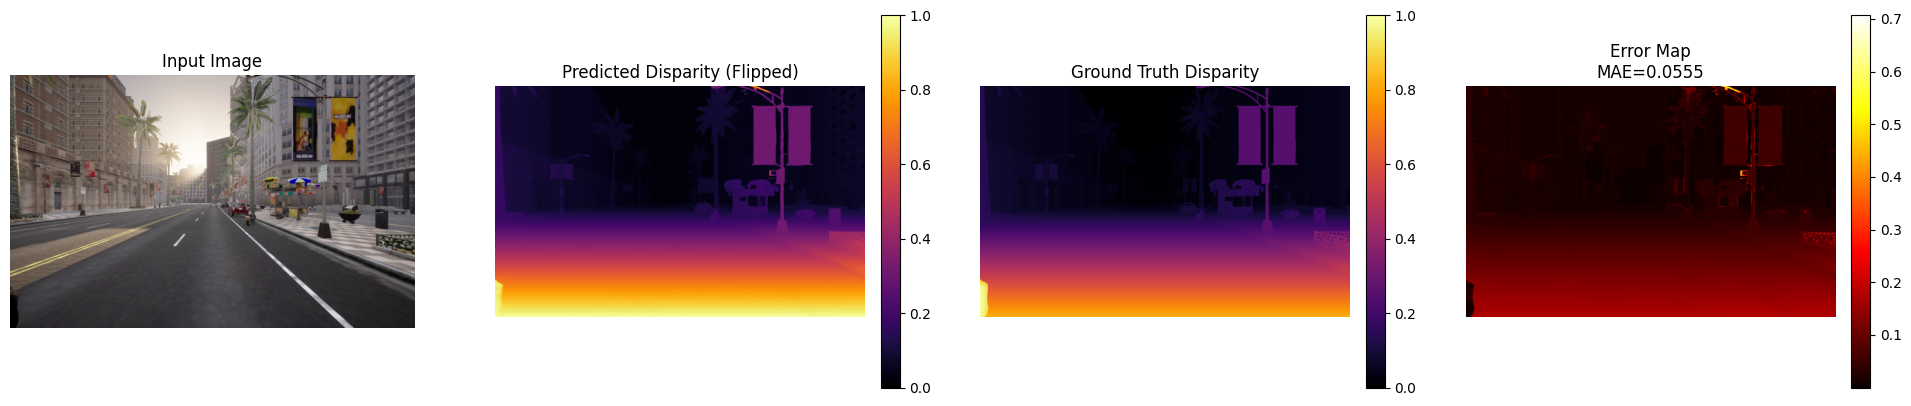

In [7]:

import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image

def visualize_stereo_example(example_name):
    img = cv2.cvtColor(cv2.imread(os.path.join(left_dir, example_name)), cv2.COLOR_BGR2RGB)
    pred_disp = cv2.imread(os.path.join(output_dir, example_name), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    gt_disp = np.array(Image.open(os.path.join(gt_disp_dir, example_name))).astype(np.float32)

    if gt_disp.shape != pred_disp.shape:
        gt_disp = cv2.resize(gt_disp, (pred_disp.shape[1], pred_disp.shape[0]))

    pred_norm = 1 - (pred_disp - pred_disp.min())/(pred_disp.max()-pred_disp.min()+1e-8)
    gt_norm = (gt_disp - gt_disp.min())/(gt_disp.max()-gt_disp.min()+1e-8)
    abs_error = np.abs(pred_norm - gt_norm)

    plt.figure(figsize=(24,6))
    titles = [
        "Input Image",
        "Predicted Disparity (Flipped)",
        "Ground Truth Disparity",
        f"Error Map\nMAE={abs_error.mean():.4f}"
    ]
    images, cmaps = [img, pred_norm, gt_norm, abs_error], [None, "inferno", "inferno", "hot"]

    for i, (im,t,cmap) in enumerate(zip(images,titles,cmaps)):
        plt.subplot(1,4,i+1)
        imshow = plt.imshow(im, cmap=cmap)
        plt.title(t); plt.axis("off")
        if cmap: plt.colorbar(imshow, fraction=0.046, pad=0.04)
    plt.show()

# Example
visualize_stereo_example(file_names[0])


## Step 5: Best and Worst Examples

- Identify the **best** and **worst** predictions based on MAE values.
- Visualize both examples to analyze:
  - Correct predictions in structured/textured regions (Best).
  - Typical failure cases such as occlusions or textureless regions (Worst).


Best Example: 489.png | MAE = 0.9995


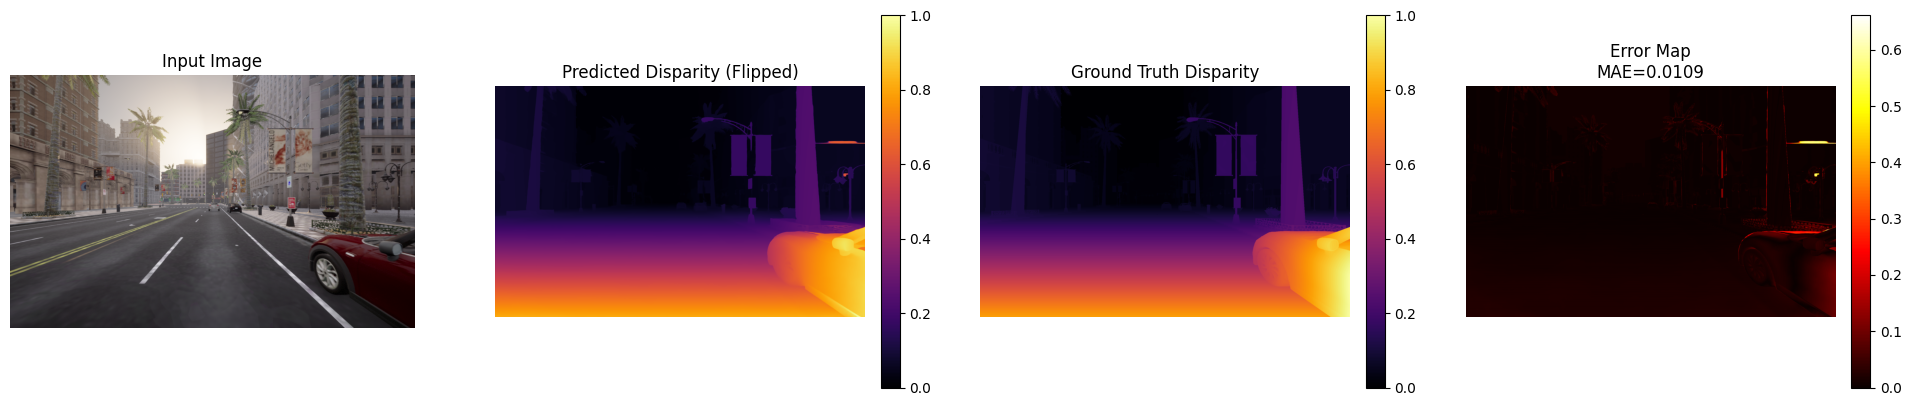

Worst Example: 485.png | MAE = 1.0126


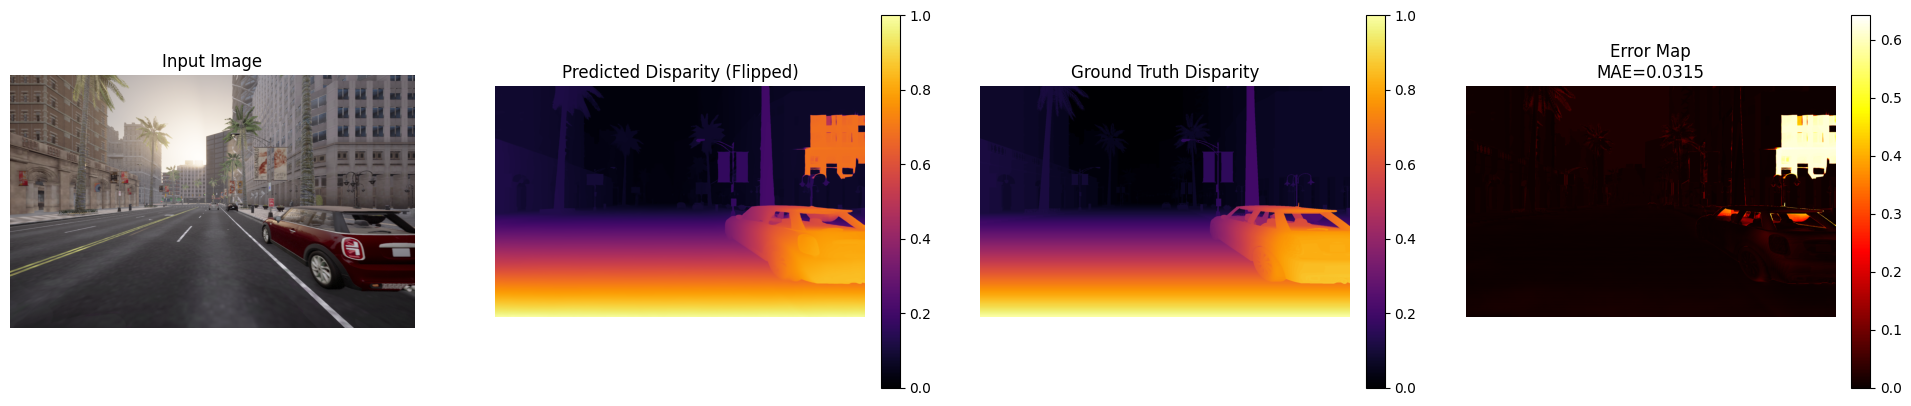

In [8]:
best_idx, worst_idx = np.argmin(MAEs), np.argmax(MAEs)
for idx, label in zip([best_idx,worst_idx], ["Best","Worst"]):
    fname = file_names[idx]
    print(f"{label} Example: {fname} | MAE = {MAEs[idx]:.4f}")
    visualize_stereo_example(fname)


## Step 6: Error Distribution Analysis

Plot histograms of MAE and RMSE across all test images to:
- Assess the overall consistency of the RAFT-Stereo model.
- Highlight the spread of prediction errors.


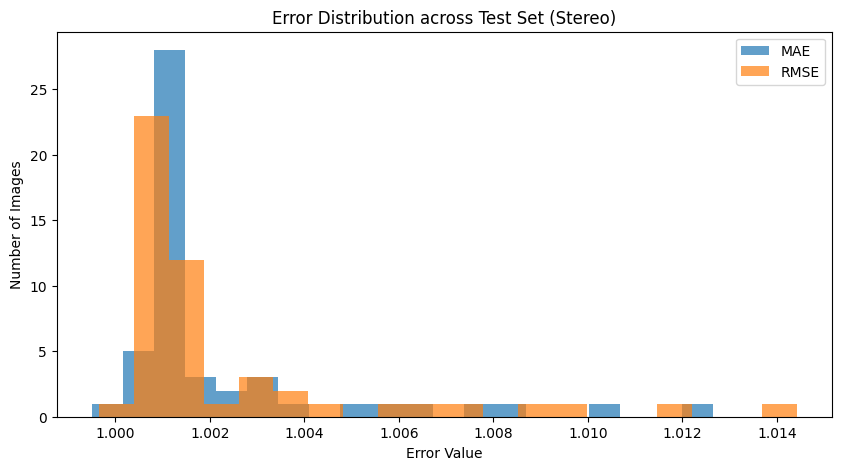

In [9]:
plt.figure(figsize=(10,5))
plt.hist(MAEs, bins=20, alpha=0.7, label="MAE")
plt.hist(RMSEs, bins=20, alpha=0.7, label="RMSE")
plt.xlabel("Error Value")
plt.ylabel("Number of Images")
plt.title("Error Distribution across Test Set (Stereo)")
plt.legend()
plt.show()
